<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica2Quest%C3%A3o3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando handel.wav de https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/main/Aula_02/Sinais_Usados/handel.wav ...
Download concluido.

Frequencia de amostragem (fs) = 8192 Hz
Numero de amostras = 73113
Duracao do sinal = 8.925 s
Frequencia de maior magnitude no espectro = 567.1 Hz


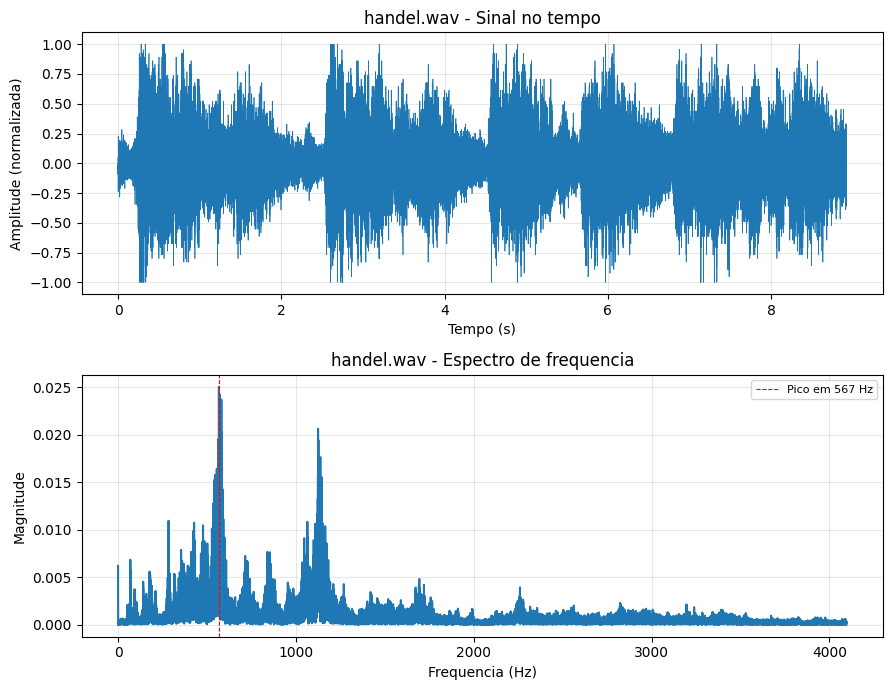

In [2]:
"""
Questao 3 - Espectro do sinal de audio handel.wav

Objetivo:
    - Ler o arquivo de audio 'handel.wav'
    - Calcular o espectro de frequencia via FFT (funcao calculate_spectrum)
    - Plotar a forma de onda no tempo e o espectro resultante

Observacao:
    'handel.wav' e um arquivo de audio classico, disponivel por padrao no
    MATLAB (load handel) e tambem poder ser baixado separadamente para uso
    em Python. Ele contem um trecho do "Hallelujah Chorus" de Handel.
    Neste codigo, assumimos que o arquivo 'handel.wav' esta na mesma pasta
    do script. Caso nao tenha o arquivo, baixe-o (por exemplo, do proprio
    MATLAB via 'audiowrite' ou de repositorios publicos) e coloque-o no
    mesmo diretorio.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile


# ---------------------------------------------------------------------------
# Funcao calculate_spectrum (mesma das questoes anteriores)
# ---------------------------------------------------------------------------
def calculate_spectrum(x, fs):
    """
    Calcula o espectro de magnitude de um sinal discreto x[n] amostrado a fs.

    Parametros
    ----------
    x  : array_like
         Vetor com as amostras do sinal no tempo.
    fs : float
         Frequencia de amostragem em Hz.

    Retorna
    -------
    freqs : ndarray
         Vetor de frequencias (Hz), somente a parte positiva (0 a fs/2).
    mag   : ndarray
         Magnitude do espectro (normalizada), correspondente a 'freqs'.
    """
    N = len(x)

    # FFT do sinal (espectro bilateral)
    X = np.fft.fft(x)

    # Vetor de frequencias associado a cada ponto da FFT
    freqs_completo = np.fft.fftfreq(N, d=1/fs)

    # Mantem somente a metade positiva (0 a fs/2)
    metade = N // 2
    freqs = freqs_completo[:metade]

    # Magnitude normalizada (compensando a energia da metade negativa)
    mag = (2.0 / N) * np.abs(X[:metade])

    return freqs, mag


# ---------------------------------------------------------------------------
# Leitura do arquivo handel.wav
# ---------------------------------------------------------------------------
# O arquivo esta hospedado no repositorio do GitHub:
#   Processamento-de-Sinais1/Aula_02/Sinais_Usados/handel.wav
#
# Se estiver rodando no Google Colab (arquivo nao esta na maquina local),
# baixamos primeiro usando a URL "raw" do GitHub. Se ja tiver o arquivo
# localmente (ex: repositorio clonado), pode pular o download e apenas
# apontar o caminho correto na variavel 'caminho_arquivo'.

import os
import urllib.request

usar_colab = True   # mude para False se estiver rodando localmente com o repo clonado

if usar_colab:
    # Troque 'main' pelo nome real da branch, caso seu repositorio use 'master'
    url = ("https://raw.githubusercontent.com/LuisTT0903/Processamento-de-Sinais1/"
           "main/Aula_02/Sinais_Usados/handel.wav")
    caminho_arquivo = "handel.wav"

    if not os.path.exists(caminho_arquivo):
        print(f"Baixando {caminho_arquivo} de {url} ...")
        urllib.request.urlretrieve(url, caminho_arquivo)
        print("Download concluido.\n")
else:
    # Caminho relativo/absoluto do arquivo ja clonado localmente
    caminho_arquivo = "Aula_02/Sinais_Usados/handel.wav"

fs, x = wavfile.read(caminho_arquivo)

# Caso o audio seja estereo (duas colunas), usamos apenas um canal
if x.ndim > 1:
    x = x[:, 0]

# Converte para float e normaliza a amplitude entre -1 e 1
# (arquivos .wav geralmente vem como inteiros de 16 bits: -32768 a 32767)
x = x.astype(np.float64)
x = x / np.max(np.abs(x))

N = len(x)
duracao = N / fs
t = np.arange(N) / fs   # vetor de tempo correspondente as amostras

print(f"Frequencia de amostragem (fs) = {fs} Hz")
print(f"Numero de amostras = {N}")
print(f"Duracao do sinal = {duracao:.3f} s")


# ---------------------------------------------------------------------------
# Calculo do espectro usando calculate_spectrum
# ---------------------------------------------------------------------------
freqs, mag = calculate_spectrum(x, fs)

# Frequencia onde ocorre o pico de maior magnitude no espectro
f_pico = freqs[np.argmax(mag)]
print(f"Frequencia de maior magnitude no espectro = {f_pico:.1f} Hz")


# ---------------------------------------------------------------------------
# Plots: forma de onda no tempo e espectro de frequencia
# ---------------------------------------------------------------------------
fig, eixos = plt.subplots(2, 1, figsize=(9, 7))

# --- Sinal no tempo ---
eixos[0].plot(t, x, linewidth=0.5)
eixos[0].set_title("handel.wav - Sinal no tempo")
eixos[0].set_xlabel("Tempo (s)")
eixos[0].set_ylabel("Amplitude (normalizada)")
eixos[0].grid(True, alpha=0.3)

# --- Espectro de frequencia ---
eixos[1].plot(freqs, mag)
eixos[1].set_title("handel.wav - Espectro de frequencia")
eixos[1].set_xlabel("Frequencia (Hz)")
eixos[1].set_ylabel("Magnitude")
eixos[1].axvline(f_pico, color='r', linestyle='--', linewidth=0.8,
                  label=f"Pico em {f_pico:.0f} Hz")
eixos[1].legend(loc="upper right", fontsize=8)
eixos[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("espectro_handel.png", dpi=150)  # salva na pasta atual
plt.show()

(b) Comentário sobre os resultados

Os resultados obtidos confirmam a diferença fundamental entre um sinal sintético (cosseno ou chirp) e um sinal real de áudio:

Frequência de amostragem baixa (fs = 8192 Hz) — diferente das questões anteriores, aqui fs não foi escolhida por nós; ela vem embutida no próprio arquivo .wav. Isso resulta em uma frequência de Nyquist de apenas 4096 Hz, o que já explica por que o eixo de frequência do espectro vai só até ~4096 Hz — qualquer componente acima disso já teria sido eliminada (ou causaria aliasing) no momento da gravação/amostragem original do arquivo.

Sinal no tempo (forma de onda) — observa-se um padrão de "rajadas" de energia, com picos de amplitude que sobem e descem ciclicamente ao longo dos ~8,9 segundos. Isso é característico de um sinal de voz/coral: cada "rajada" corresponde a uma frase ou trecho cantado, separado por pausas (respiração, silêncio entre frases), diferente da amplitude constante de um cosseno puro.

Espectro de frequência — múltiplos picos, não um único tom — ao contrário dos sinais das Questões 1 e 2 (que geravam picos únicos e bem definidos), o espectro do handel.wav mostra vários picos distribuídos, com destaque para:

Um pico dominante em ~567 Hz
Um segundo pico relevante próximo de ~1100–1150 Hz (aproximadamente o dobro do pico principal — provavelmente um harmônico)
Diversos picos menores espalhados até cerca de 2000–2500 Hz, e uma "cauda" de energia residual até o limite de Nyquist (4096 Hz)

Isso é esperado porque voz e música não são sinais senoidais puros — são compostos por uma frequência fundamental (a nota/tom predominante cantado, aqui em torno de 567 Hz, próximo de um Dó5 ~523 Hz ou Ré5 ~587 Hz) somada a diversos harmônicos (múltiplos inteiros da fundamental) e componentes de outras vozes/instrumentos tocando simultaneamente, o que gera esse espectro rico e multi-picos.

Conclusão geral — o experimento evidencia a diferença entre sinais determinísticos simples (cosseno, chirp) e sinais reais complexos (voz/música): enquanto os primeiros produzem espectros previsíveis e concentrados em poucas frequências (ou faixas bem definidas, no caso do chirp), um sinal de áudio real como o handel.wav apresenta um espectro rico em harmônicos e componentes espalhadas, refletindo a superposição de múltiplas fontes sonoras (vozes, instrumentos) e a natureza não-estacionária do sinal (a frequência dominante muda ao longo do tempo, conforme a melodia é cantada) — algo que a FFT sobre o sinal inteiro só consegue mostrar de forma "média", sem indicar em que instante cada componente ocorre (para isso, seria necessário uma análise tempo-frequência, como um espectrograma).